# Práctica 1. Aprendizaje Automático

## Grado en Ingeniería Informática - UC3M

- Ernesto González Cerezo: 100522276@alumnos.uc3m.es
- David Benito Gil: 100522289@alumnos.uc3m.es



## 1. Introducción y Objetivos


Esta práctica trata sobre la creación y entrenamiento de un modelo predictivo orientado al mundo financiero, más concretamente, a los préstamos de un banco.

Se quiere predecir, a partir de una serie de datos de un cliente, si éste aceptará el producto o no.

## 2. EDA simplificado


El primer paso para realizar el análisis explorativo de datos (EDA) es determinar cuántas variables e instancias hay en el conjunto de datos.

### Carga del dataset desde GitHub

In [2]:
!rm -rf p1-aprendizaje-automatico-100522276-100522289
!git clone https://github.com/egonzalez100522276/p1-aprendizaje-automatico-100522276-100522289.git

Cloning into 'p1-aprendizaje-automatico-100522276-100522289'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (34/34), done.
remote: Total 131 (delta 104), reused 102 (delta 96), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 1.16 MiB | 1.28 MiB/s, done.
Resolving deltas: 100% (104/104), done.


In [3]:
import pandas as pd
import numpy as np

# Definir la ruta al dataset
DATASET_PATH = "p1-aprendizaje-automatico-100522276-100522289/bank_ALL/bank_17.pkl"

# Cambia el nombre por tu fichero real
df = pd.read_pickle(DATASET_PATH)

print("Shape (filas, columnas):", df.shape)
#display(df.head(3))
# Fijar la semilla 'random_state' para garantizar la reproducibilidad
display(df.sample(10, random_state=42))

Shape (filas, columnas): (11000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
109,41,blue-collar,married,primary,no,1250,yes,no,unknown,20,may,1392,2,-1,0,unknown,yes
5555,36,technician,married,secondary,no,0,yes,no,cellular,21,jul,193,5,-1,0,unknown,no
7093,45,services,married,unknown,no,8319,no,no,cellular,15,jun,75,2,-1,0,unknown,no
4028,32,student,single,secondary,no,1102,no,no,telephone,8,oct,194,1,-1,0,unknown,yes
3146,68,retired,married,tertiary,no,2812,no,no,cellular,3,feb,279,2,181,1,failure,yes
4085,46,technician,married,unknown,no,3308,no,no,cellular,27,oct,171,1,91,2,success,yes
3046,25,technician,married,tertiary,no,2551,no,no,cellular,28,dec,400,3,-1,0,unknown,yes
6696,30,admin.,married,secondary,no,350,no,yes,cellular,9,jul,171,5,-1,0,unknown,no
4266,35,management,single,tertiary,no,7918,no,no,cellular,7,sep,497,1,-1,0,unknown,yes
8878,45,blue-collar,married,secondary,no,-221,yes,yes,unknown,3,jun,170,1,-1,0,unknown,no


### Análisis de las variables


#### Identificación de variables categóricas

In [4]:
import pandas as pd

# Columnas categóricas
cat_cols = df.select_dtypes(include=["object"]).columns

resumen = []

# Obtener cardinalidades de cada variable categórica
for col in cat_cols:
    cardinalidad = df[col].nunique()
    valores = df[col].dropna().unique().tolist()
    alta_card = cardinalidad > 10   # umbral arbitrario

    # Añadir columnas a la tabla
    resumen.append({
        "Variable": col,
        "Cardinalidad": cardinalidad,
        "Valores posibles": valores,
        "Alta cardinalidad (> 10)": alta_card
    })

# Construir la tabla
tabla_resumen = pd.DataFrame(resumen)

# Mostrar tabla
tabla_resumen

,Variable,Cardinalidad,Valores posibles,Alta cardinalidad (> 10)
0,job,12,"[admin., technician, services, management, ret...",True
1,marital,3,"[married, single, divorced]",False
2,education,4,"[secondary, tertiary, primary, unknown]",False
3,default,2,"[no, yes]",False
4,housing,2,"[yes, no]",False
5,loan,2,"[no, yes]",False
6,contact,3,"[unknown, cellular, telephone]",False
7,month,12,"[may, jun, jul, aug, oct, nov, dec, jan, feb, ...",True
8,poutcome,4,"[unknown, other, failure, success]",False
9,deposit,2,"[yes, no]",False


#### Missing Values /NA's

In [5]:
# Identificar variables con missing values
import numpy as np

resumen = []

for col in df.columns:
    # En pdays, los missing values se codifican con "-1"
    if col == "pdays":
        missing = df[col].isna().sum() + (df[col] == -1).sum()

    # El valor 'unknown' se computa como missing value
    else:
        missing = df[col].isna().sum() + (df[col] == "unknown").sum()
    # Añadir columnas a la tabla
    resumen.append({
        "Variable": col,
        "Missing totales": missing,
        "% Missing": (missing / len(df)) * 100
    })
# Construir la tabla
tabla_missing = pd.DataFrame(resumen).sort_values("% Missing", ascending=False)

# Mostrar tabla
tabla_missing

,Variable,Missing totales,% Missing
15,poutcome,8205,74.590909
13,pdays,8203,74.572727
8,contact,2309,20.990909
3,education,860,7.818182
1,job,68,0.618182
0,age,0,0.000000
5,balance,0,0.000000
4,default,0,0.000000
2,marital,0,0.000000
7,loan,0,0.000000


La variable *pdays* indica el número de días transcurridos desde el último contacto con el cliente en una campaña anterior.

En este dataset el valor -1 indica que el cliente no fue contactado previamente, por lo que no representa un valor perdido real sino una codificación especial.

Por otro lado, la variable *poutcome* presenta un alto porcentaje de valores unknown, lo cual indica que en muchos casos no existe información sobre el resultado de campañas anteriores.

#### Columnas constantes y columnas tipo ID

In [6]:
# Construir tabla de columnas constantes
tabla_constantes = pd.DataFrame({
    "Variable": df.columns,
    "Valores únicos": df.nunique(dropna=False)
})

tabla_constantes = tabla_constantes[tabla_constantes["Valores únicos"] == 1]

tabla_constantes

,Variable,Valores únicos


In [7]:
# Construir tabla de columnas tipo ID
tabla_id = pd.DataFrame({
    "Variable": df.columns,
    "Cardinalidad": df.nunique(),
})

tabla_id["% unicidad"] = tabla_id["Cardinalidad"] / len(df)
tabla_id["¿Es columna ID?"] = tabla_id["% unicidad"] > 0.95  # umbral arbitrario

tabla_id = tabla_id.sort_values("% unicidad", ascending=False)

tabla_id
tabla_id[tabla_id["¿Es columna ID?"]]

,Variable,Cardinalidad,% unicidad,¿Es columna ID?


Se ha analizado si existen columnas que puedan actuar como identificadores únicos de las instancias. Para ello se ha calculado el porcentaje de unicidad de cada variable respecto al número total de instancias.

No se han encontrado variables con un porcentaje de unicidad cercano al 100%, por lo que se concluye que no existen columnas tipo ID en el dataset.

#### Tipo de problema

In [8]:
df["deposit"].value_counts()

,count
deposit,
no,5780
yes,5220


Viendo este resultado se puede ver claramente un tipo de problema de clasificación y en este caso binaria (yes, no)

#### Desbalanceo

In [9]:
df["deposit"].value_counts(normalize=True) * 100

,proportion
deposit,
no,52.545455
yes,47.454545


Viendo que las clases están más o menos cerca, se podría decir que no está fuertemente desbalanceado.

# 3. Método de Evaluación

## Elección de métrica de evaluación

A la hora de elegir la métrica más adecuada, es fundamental mirar ante qué tipo de problema nos encontramos: **clasificación binaria**.

#### Accuracy
Inicialmlente, se nos vino a la cabeza la métrica de **Accuracy**, pero nos dimos cuenta de que tiene un problema fundamental al aplicarla a clasificación binaria, y es que si la proporción entre clases está descompensada y una clase es muy mayoritaria, un modelo naive que siempre prediga la clase predominante tendrá una gran accuracy, siendo ciego al resto de variables y sin capturar patrones en el dataset.

#### F1-score
Esta métrica combina *precision* y *recall*, guardando un buen equilibrio entre **no perder potenciales clientes** (gracias al *recall*), y **no contactar a clientes potencialmente no interesados** (gracias a *precision*).

Por tanto, **elegiremos F1-Score** como métrica de evaluación para el modelo durante la práctica.

## Holdout
El split elegido es **Holdout**, dedicando 2/3 del dataset a *train*, y 1/3 a *test*.

In [10]:
from sklearn.model_selection import train_test_split

# Definimos nuestros conjuntos X e Y
X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,   # 1/3 test, 2/3 train
    random_state=42,  # reproducibilidad
    stratify=y
)

# Comprobaciones
print("------------------------------")
print("Tamaño de train:", len(X_train))
print("Tamaño de test:", len(X_test))
print("------------------------------")
print("Forma de X_train: ", X_train.shape)
print("Forma de X_test: ", X_test.shape)
print("------------------------------")
print("Proporción de clases en train:")
print(y_train.value_counts(normalize=True) * 100)
print("\n")
print("Proporción de clases en test:")
print(y_test.value_counts(normalize=True) * 100)

------------------------------
Tamaño de train: 7333
Tamaño de test: 3667
------------------------------
Forma de X_train:  (7333, 16)
Forma de X_test:  (3667, 16)
------------------------------
Proporción de clases en train:
deposit
no     52.543297
yes    47.456703
Name: proportion, dtype: float64


Proporción de clases en test:
deposit
no     52.549768
yes    47.450232
Name: proportion, dtype: float64


# 4. Preprocesado de los datos

Antes de entrenar los modelos, es necesario aplicar un preprocesado a los datos.

En las variables numéricas se imputarán los posibles valores faltantes con la media.  
En las variables categóricas se imputarán con el valor más frecuente y después se aplicará una codificación One-Hot Encoding para poder utilizarlas en los modelos.

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identificación de variables numéricas y categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print("Variables numéricas:", list(num_cols))
print("Variables categóricas:", list(cat_cols))

Variables numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


Se observa que el conjunto de entrenamiento contiene 7 variables numéricas y 9 variables categóricas.  
Esto hace necesario aplicar un preprocesado diferente a cada tipo de variable.

## Construcción del preprocesador
Se construye un preprocesador mediante `ColumnTransformer`, aplicando imputación por media a las variables numéricas e imputación por moda junto con One-Hot Encoding a las variables categóricas.

In [12]:
# Pipeline para variables numéricas
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Pipeline para variables categóricas
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocesador completo
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer())]),
                                 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])

## Evaluación interna y preparación para los modelos

Hasta este punto ya se ha realizado la separación holdout entre entrenamiento y test, que se utilizará al final para estimar el rendimiento futuro del modelo seleccionado.

Sin embargo, para comparar distintas alternativas de modelado y para ajustar hiperparámetros, es necesario definir también un procedimiento de evaluación interna. En esta práctica se utilizará validación cruzada estratificada de 3 particiones sobre el conjunto de entrenamiento, siguiendo el esquema general indicado para la práctica.

Además, antes de entrenar los modelos, se deja preparado un preprocesado común que se reutilizará en las siguientes secciones.

In [13]:
from sklearn.model_selection import StratifiedKFold

# Evaluación interna (inner)
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

print(cv_inner)

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)


## Comparación de escalados para KNN

El método KNN es especialmente sensible a la escala de las variables numéricas, ya que calcula distancias entre observaciones. Por ello, antes de comparar KNN con otros métodos, conviene decidir qué estrategia de escalado funciona mejor en este problema.

Se compararán tres alternativas habituales:
- `StandardScaler`
- `MinMaxScaler`
- `RobustScaler`

La comparación se realizará mediante validación cruzada estratificada de 3 particiones sobre el conjunto de entrenamiento, utilizando como métrica principal el F1-score.

In [14]:
from sklearn.metrics import make_scorer, f1_score

f1_yes = make_scorer(f1_score, pos_label="yes")
print(f1_yes)

make_scorer(f1_score, response_method='predict', pos_label=yes)


In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

resultados_scalers = []

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

for nombre_scaler, scaler in scalers.items():
    preprocessor_knn = ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="mean")),
                ("scaler", scaler)
            ]), num_cols),
            ("cat", Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_cols)
        ]
    )

    pipeline_knn = Pipeline(steps=[
        ("preprocessor", preprocessor_knn),
        ("classifier", KNeighborsClassifier())
    ])

    scores = cross_val_score(
        pipeline_knn,
        X_train,
        y_train,
        cv=cv_inner,
        scoring=f1_yes,
        n_jobs=-1
    )

    resultados_scalers.append({
        "Scaler": nombre_scaler,
        "F1 medio": scores.mean(),
        "Desviación típica": scores.std()
    })

tabla_scalers = pd.DataFrame(resultados_scalers).sort_values(by="F1 medio", ascending=False)
tabla_scalers

,Scaler,F1 medio,Desviación típica
0,StandardScaler,0.785578,0.015422
2,RobustScaler,0.765773,0.017662
1,MinMaxScaler,0.709946,0.012835


A partir de esta comparación se seleccionará el escalado que obtenga el mejor F1-score medio. Ese escalado será el que se utilizará en adelante para KNN y para otros métodos que también puedan verse afectados por la escala de las variables.

In [16]:
mejor_scaler = tabla_scalers.iloc[0]["Scaler"]
print("El mejor escalado para KNN es:", mejor_scaler)

El mejor escalado para KNN es: StandardScaler


## Métodos básicos con hiperparámetros por defecto

Una vez seleccionado el escalado más adecuado para KNN, se procede a evaluar los métodos básicos pedidos en la práctica con sus hiperparámetros por omisión.

En esta sección se compararán tres alternativas:
- un modelo trivial de referencia (*Dummy Classifier*),
- KNN con los valores por defecto,
- un árbol de decisión con los valores por defecto.

La comparación se realizará utilizando validación cruzada estratificada de 3 particiones sobre el conjunto de entrenamiento, empleando como métrica principal el F1-score. Además, se medirá el tiempo de entrenamiento de cada alternativa, ya que la práctica también pide analizar el coste computacional de los distintos métodos.

In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

if mejor_scaler == "StandardScaler":
    scaler_seleccionado = StandardScaler()
elif mejor_scaler == "MinMaxScaler":
    scaler_seleccionado = MinMaxScaler()
else:
    scaler_seleccionado = RobustScaler()

print("Scaler seleccionado para KNN:", scaler_seleccionado)

Scaler seleccionado para KNN: StandardScaler()


In [18]:
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
import time
import pandas as pd

In [19]:
# Pipeline para Dummy
preprocessor_dummy = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

pipeline_dummy = Pipeline(steps=[
    ("preprocessor", preprocessor_dummy),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

pipeline_dummy

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', DummyClassifier(strategy='most_frequent'))])

In [20]:
# Pipeline para KNN con hiperparámetros por defecto
preprocessor_knn_default = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", scaler_seleccionado)
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

pipeline_knn_default = Pipeline(steps=[
    ("preprocessor", preprocessor_knn_default),
    ("classifier", KNeighborsClassifier())
])

pipeline_knn_default

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', KNeighborsClassifier())])

In [21]:
# Pipeline para árbol de decisión con hiperparámetros por defecto
preprocessor_tree_default = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean"))
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

pipeline_tree_default = Pipeline(steps=[
    ("preprocessor", preprocessor_tree_default),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

pipeline_tree_default

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [22]:
from sklearn.metrics import make_scorer, f1_score

f1_scorer = make_scorer(f1_score, pos_label="yes")
print("Scorer F1 definido correctamente.")

Scorer F1 definido correctamente.


In [23]:
resultados_default = []

modelos_default = {
    "Dummy": pipeline_dummy,
    "KNN default": pipeline_knn_default,
    "Tree default": pipeline_tree_default
}

for nombre_modelo, pipeline_modelo in modelos_default.items():
    inicio = time.perf_counter()

    scores = cross_val_score(
        pipeline_modelo,
        X_train,
        y_train,
        cv=cv_inner,
        scoring=f1_scorer,
        n_jobs=-1
    )

    fin = time.perf_counter()

    resultados_default.append({
        "Modelo": nombre_modelo,
        "F1 medio": scores.mean(),
        "Desviación típica": scores.std(),
        "Tiempo total CV (s)": fin - inicio
    })

tabla_default = pd.DataFrame(resultados_default).sort_values(
    by="F1 medio",
    ascending=False
)

tabla_default

,Modelo,F1 medio,Desviación típica,Tiempo total CV (s)
1,KNN default,0.785578,0.015422,1.242222
2,Tree default,0.777466,0.007536,0.690429
0,Dummy,0.000000,0.000000,0.638959


La tabla anterior permite comparar el comportamiento inicial de los métodos básicos sin ajustar todavía sus hiperparámetros.

En primer lugar, el modelo *Dummy* actúa como referencia trivial. Su función es proporcionar una línea base mínima con la que comprobar si los métodos reales están aprendiendo patrones útiles del conjunto de datos.

A continuación, se observa el rendimiento de KNN con sus valores por defecto y el de un árbol de decisión también con configuración por omisión. Además del F1-score medio, se incluye el tiempo total requerido para realizar la validación cruzada, lo que permite valorar no solo la calidad predictiva, sino también el coste computacional asociado a cada alternativa.

In [24]:
mejor_modelo_default = tabla_default.iloc[0]["Modelo"]
print("El mejor método básico con hiperparámetros por defecto es:", mejor_modelo_default)

El mejor método básico con hiperparámetros por defecto es: KNN default


Como primera conclusión, esta comparación permite comprobar si KNN o los árboles de decisión mejoran claramente al modelo trivial.

En caso de que exista una mejora apreciable frente al *Dummy Classifier*, se podrá concluir que los métodos sí están capturando información útil del dataset. No obstante, esta comparación todavía es preliminar, ya que el siguiente paso será ajustar los hiperparámetros más importantes de cada método para comprobar si es posible mejorar aún más el rendimiento.

## Interpretación mediante un árbol poco profundo

Además de comparar el rendimiento predictivo de los métodos, la práctica pide utilizar árboles poco profundos para obtener una interpretación sencilla de cómo pueden tomarse decisiones en este problema.

La idea de esta sección no es maximizar el rendimiento, sino construir un árbol pequeño y fácilmente interpretable, de manera que se pueda observar qué variables aparecen en los primeros niveles y qué tipo de reglas generan.

In [25]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

pipeline_tree_shallow = Pipeline(steps=[
    ("preprocessor", preprocessor_tree_default),
    ("classifier", DecisionTreeClassifier(max_depth=3, random_state=42))
])

pipeline_tree_shallow.fit(X_train, y_train)

print("Árbol poco profundo entrenado correctamente.")

Árbol poco profundo entrenado correctamente.


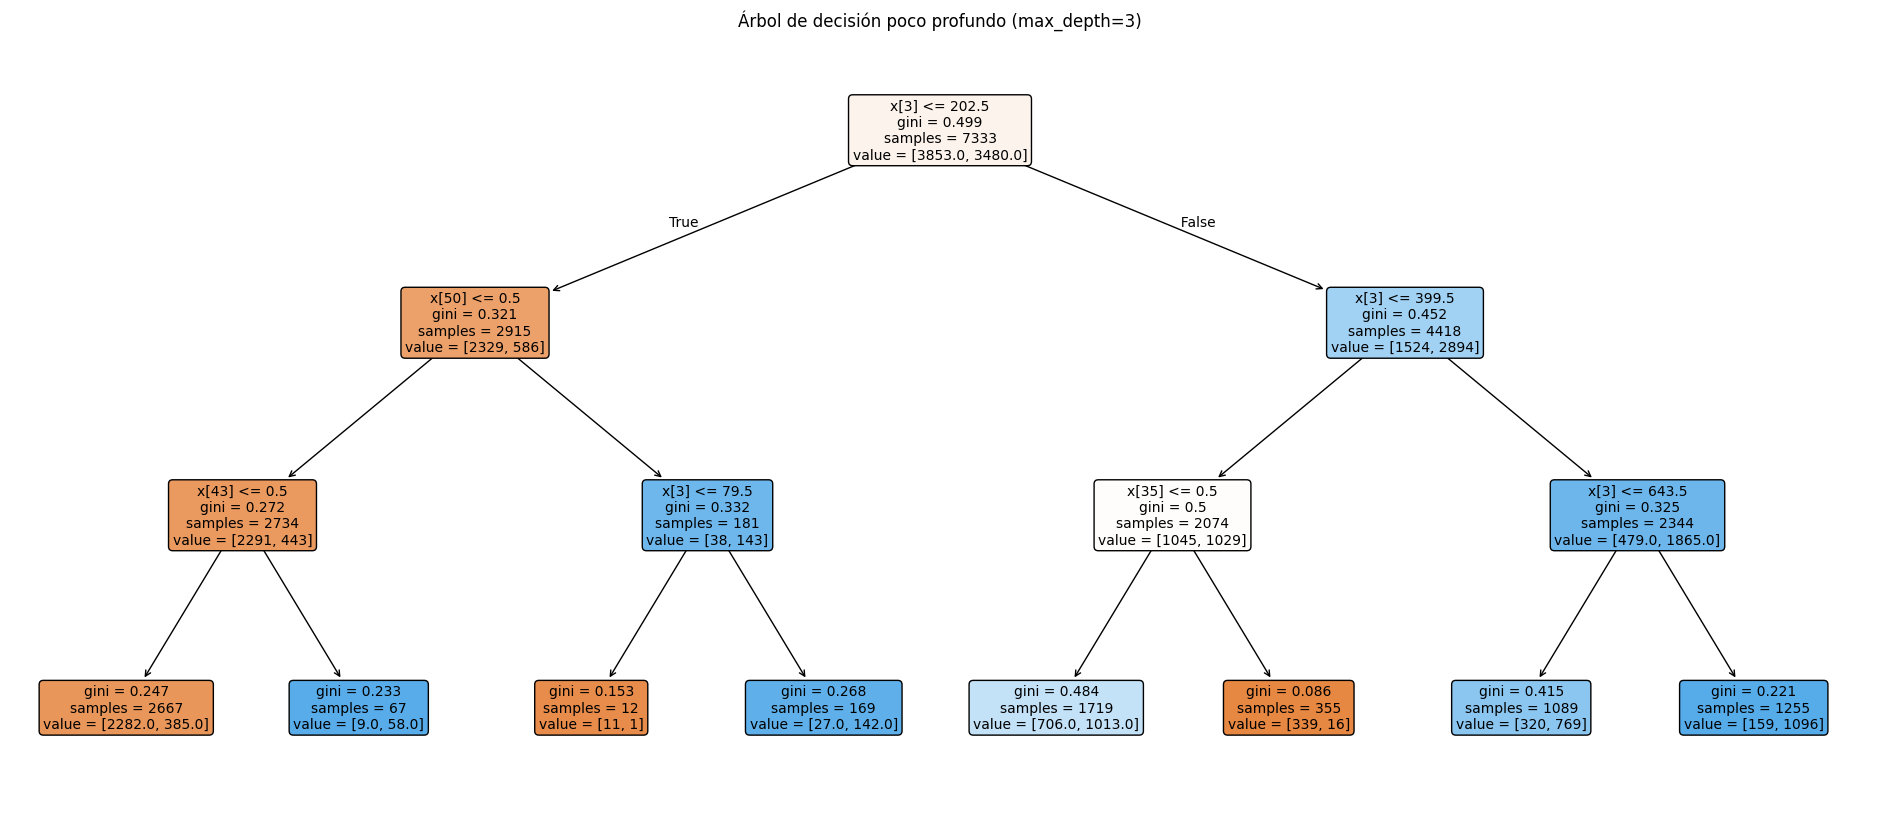

In [26]:
plt.figure(figsize=(24, 10))

plot_tree(
    pipeline_tree_shallow.named_steps["classifier"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de decisión poco profundo (max_depth=3)")
plt.show()

El árbol mostrado permite obtener una primera interpretación del problema. Aunque al haber aplicado un preprocesado con codificación *one-hot* los nodos no muestran directamente todas las variables originales de forma intuitiva, sí permite observar qué particiones generan decisiones tempranas y cómo un árbol pequeño puede separar parte de los casos positivos y negativos.

Este tipo de representación resulta útil como apoyo interpretativo, aunque no necesariamente corresponde al modelo con mejor rendimiento.

## Optimización de hiperparámetros en KNN

Una vez evaluado KNN con sus hiperparámetros por defecto, el siguiente paso es ajustar sus parámetros más importantes para comprobar si es posible mejorar el rendimiento.

En este caso, se optimizarán principalmente:
- el número de vecinos `n_neighbors`,
- el tipo de ponderación `weights`,
- y la métrica de distancia `p`, que permite comparar distancia Manhattan (`p=1`) y Euclídea (`p=2`).

La búsqueda se realizará mediante validación cruzada estratificada de 3 particiones sobre el conjunto de entrenamiento.

In [27]:
from sklearn.model_selection import GridSearchCV

In [28]:
pipeline_knn_hpo = Pipeline(steps=[
    ("preprocessor", preprocessor_knn_default),
    ("classifier", KNeighborsClassifier())
])

param_grid_knn = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11, 15],
    "classifier__weights": ["uniform", "distance"],
    "classifier__p": [1, 2]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn_hpo,
    param_grid=param_grid_knn,
    scoring=f1_scorer,
    cv=cv_inner,
    n_jobs=-1,
    refit=True
)

inicio_knn_hpo = time.perf_counter()
grid_knn.fit(X_train, y_train)
fin_knn_hpo = time.perf_counter()

print("Mejores parámetros KNN:", grid_knn.best_params_)
print("Mejor F1 medio KNN:", grid_knn.best_score_)
print("Tiempo HPO KNN (s):", fin_knn_hpo - inicio_knn_hpo)

Mejores parámetros KNN: {'classifier__n_neighbors': 11, 'classifier__p': 2, 'classifier__weights': 'distance'}
Mejor F1 medio KNN: 0.7912764750237035
Tiempo HPO KNN (s): 18.027277785000024


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [       nan 0.75407571 0.7719659  0.77241125        nan 0.77106167
 0.78557772 0.78606453        nan 0.77472679 0.78649232 0.79056365
        nan 0.77223246 0.78658462 0.79015133        nan 0.77233506
 0.78786342 0.79127648        nan 0.77256047 0.78795402 0.79065974]
  warnings.warn(


In [29]:
resultados_knn_hpo = pd.DataFrame(grid_knn.cv_results_)

tabla_knn_hpo = resultados_knn_hpo[[
    "param_classifier__n_neighbors",
    "param_classifier__weights",
    "param_classifier__p",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values(by="rank_test_score")

tabla_knn_hpo.head(10)

,param_classifier__n_neighbors,param_classifier__weights,param_classifier__p,mean_test_score,std_test_score,rank_test_score
19,11,distance,2,0.791276,0.015318,1
23,15,distance,2,0.790660,0.018387,2
11,7,distance,2,0.790564,0.012921,3
15,9,distance,2,0.790151,0.017959,4
22,15,uniform,2,0.787954,0.017467,5
18,11,uniform,2,0.787863,0.015610,6
14,9,uniform,2,0.786585,0.019559,7
10,7,uniform,2,0.786492,0.014981,8
7,5,distance,2,0.786065,0.014511,9
6,5,uniform,2,0.785578,0.015422,10


La tabla anterior recoge las combinaciones de hiperparámetros probadas para KNN y su rendimiento medio en validación cruzada. De este modo, es posible comprobar si el ajuste de hiperparámetros mejora o no el resultado obtenido inicialmente con la configuración por defecto.

## Optimización de hiperparámetros en árboles de decisión

A continuación se repite el mismo procedimiento con árboles de decisión. En este caso, algunos de los hiperparámetros más relevantes son la profundidad máxima del árbol, el número mínimo de muestras necesarias para dividir un nodo y el número mínimo de muestras exigidas en una hoja.

Estos parámetros permiten controlar la complejidad del árbol y ayudan a evitar tanto árboles excesivamente simples como árboles sobreajustados.

In [30]:
pipeline_tree_hpo = Pipeline(steps=[
    ("preprocessor", preprocessor_tree_default),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

param_grid_tree = {
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10, 20],
    "classifier__min_samples_leaf": [1, 2, 5, 10]
}

grid_tree = GridSearchCV(
    estimator=pipeline_tree_hpo,
    param_grid=param_grid_tree,
    scoring=f1_scorer,
    cv=cv_inner,
    n_jobs=-1,
    refit=True
)

inicio_tree_hpo = time.perf_counter()
grid_tree.fit(X_train, y_train)
fin_tree_hpo = time.perf_counter()

print("Mejores parámetros Tree:", grid_tree.best_params_)
print("Mejor F1 medio Tree:", grid_tree.best_score_)
print("Tiempo HPO Tree (s):", fin_tree_hpo - inicio_tree_hpo)

Mejores parámetros Tree: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10}
Mejor F1 medio Tree: 0.8123747929033208
Tiempo HPO Tree (s): 21.548708659


In [31]:
resultados_tree_hpo = pd.DataFrame(grid_tree.cv_results_)

tabla_tree_hpo = resultados_tree_hpo[[
    "param_classifier__max_depth",
    "param_classifier__min_samples_split",
    "param_classifier__min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values(by="rank_test_score")

tabla_tree_hpo.head(10)

,param_classifier__max_depth,param_classifier__min_samples_split,param_classifier__min_samples_leaf,mean_test_score,std_test_score,rank_test_score
50,10,10,1,0.812375,0.006285,1
57,10,5,5,0.811311,0.006591,2
56,10,2,5,0.811311,0.006591,2
58,10,10,5,0.811311,0.006591,2
51,10,20,1,0.811181,0.004494,5
59,10,20,5,0.810836,0.008008,6
54,10,10,2,0.810462,0.006090,7
55,10,20,2,0.810374,0.006737,8
47,7,20,10,0.809880,0.005161,9
46,7,10,10,0.809880,0.005161,9


De forma análoga a KNN, esta búsqueda permite estudiar qué combinaciones de hiperparámetros producen mejores resultados en árboles de decisión y si el ajuste aporta una mejora apreciable respecto al modelo por defecto.

## Comparación de resultados en métodos básicos

Una vez evaluados los métodos básicos con sus valores por defecto y tras realizar la optimización de hiperparámetros, ya se dispone de la información necesaria para compararlos de forma más completa.

En particular, interesa responder a varias preguntas:
- si KNN o árboles mejoran al modelo trivial,
- si el ajuste de hiperparámetros aporta mejoras respecto a los valores por defecto,
- y cuál es el coste computacional asociado a esas mejoras.

In [32]:
resumen_metodos_basicos = pd.DataFrame([
    {
        "Modelo": "Dummy",
        "F1 medio": tabla_default.loc[tabla_default["Modelo"] == "Dummy", "F1 medio"].values[0],
        "Tiempo (s)": tabla_default.loc[tabla_default["Modelo"] == "Dummy", "Tiempo total CV (s)"].values[0]
    },
    {
        "Modelo": "KNN default",
        "F1 medio": tabla_default.loc[tabla_default["Modelo"] == "KNN default", "F1 medio"].values[0],
        "Tiempo (s)": tabla_default.loc[tabla_default["Modelo"] == "KNN default", "Tiempo total CV (s)"].values[0]
    },
    {
        "Modelo": "KNN HPO",
        "F1 medio": grid_knn.best_score_,
        "Tiempo (s)": fin_knn_hpo - inicio_knn_hpo
    },
    {
        "Modelo": "Tree default",
        "F1 medio": tabla_default.loc[tabla_default["Modelo"] == "Tree default", "F1 medio"].values[0],
        "Tiempo (s)": tabla_default.loc[tabla_default["Modelo"] == "Tree default", "Tiempo total CV (s)"].values[0]
    },
    {
        "Modelo": "Tree HPO",
        "F1 medio": grid_tree.best_score_,
        "Tiempo (s)": fin_tree_hpo - inicio_tree_hpo
    }
]).sort_values(by="F1 medio", ascending=False)

resumen_metodos_basicos

,Modelo,F1 medio,Tiempo (s)
4,Tree HPO,0.812375,21.548709
2,KNN HPO,0.791276,18.027278
1,KNN default,0.785578,1.242222
3,Tree default,0.777466,0.690429
0,Dummy,0.000000,0.638959


A partir de esta tabla resumen ya se puede extraer una primera conclusión sobre los métodos básicos. En particular, se puede observar qué modelo obtiene el mejor F1-score medio dentro de esta familia, si la optimización de hiperparámetros aporta una mejora clara y hasta qué punto dicha mejora compensa el incremento en tiempo de cómputo.

Con esto queda cerrada la comparación principal entre KNN y árboles. En la siguiente sección se abordarán los métodos avanzados pedidos en la práctica: modelos lineales y SVM.

# 5. Métodos avanzados: modelos lineales y SVM

En esta sección se estudiarán dos familias de métodos más avanzados que también se piden en la práctica: los modelos lineales y las máquinas de vectores soporte (SVM).

Primero se evaluarán ambas alternativas con sus hiperparámetros por defecto, utilizando la misma estrategia de validación cruzada interna definida anteriormente. Después, se ajustarán algunos de sus hiperparámetros más relevantes para comprobar si es posible mejorar el rendimiento. Igual que en los métodos básicos, además del F1-score se tendrá en cuenta el tiempo de entrenamiento.

Por último, se analizará si alguno de estos métodos permite extraer información útil sobre qué variables parecen más relevantes para la predicción.

## 5.1 Evaluación con hiperparámetros por defecto

Se comenzará evaluando un modelo lineal y un modelo SVM con sus configuraciones por defecto. Dado que ambos métodos son sensibles a la escala de las variables, se utilizará un preprocesado con escalado en las variables numéricas, además de la imputación y la codificación necesarias en las variables categóricas.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [34]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

preprocessor_scaled

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])

In [35]:
pipeline_linear_default = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

pipeline_linear_default

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [36]:
pipeline_svm_default = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", SVC(random_state=42))
])

pipeline_svm_default

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier', SVC(random_state=42))])

In [37]:
resultados_avanzados_default = []

modelos_avanzados_default = {
    "Logistic Regression default": pipeline_linear_default,
    "SVM default": pipeline_svm_default
}

for nombre_modelo, pipeline_modelo in modelos_avanzados_default.items():
    inicio = time.perf_counter()

    scores = cross_val_score(
        pipeline_modelo,
        X_train,
        y_train,
        cv=cv_inner,
        scoring=f1_scorer,
        n_jobs=-1
    )

    fin = time.perf_counter()

    resultados_avanzados_default.append({
        "Modelo": nombre_modelo,
        "F1 medio": scores.mean(),
        "Desviación típica": scores.std(),
        "Tiempo total CV (s)": fin - inicio
    })

tabla_avanzados_default = pd.DataFrame(resultados_avanzados_default).sort_values(
    by="F1 medio",
    ascending=False
)

tabla_avanzados_default

,Modelo,F1 medio,Desviación típica,Tiempo total CV (s)
1,SVM default,0.852310,0.007853,3.46033
0,Logistic Regression default,0.820585,0.007533,0.29772


La tabla anterior permite observar el rendimiento inicial de los métodos avanzados con sus hiperparámetros por defecto. Esta comparación ofrece una primera idea de si los modelos lineales o las SVM pueden competir con los mejores métodos básicos obtenidos en la sección anterior.

## 5.2 Optimización de hiperparámetros en modelos lineales

En el caso del modelo lineal, se utilizará una regresión logística y se ajustarán algunos hiperparámetros relacionados con la regularización. En particular, interesa comparar regularización L2 y regularización L1, ya que esta última puede favorecer modelos más dispersos y facilitar la interpretación de la relevancia de los atributos.

In [38]:
pipeline_linear_hpo = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])

param_grid_linear = [
    {
        "classifier__penalty": ["l2"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["lbfgs"]
    },
    {
        "classifier__penalty": ["l1"],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__solver": ["liblinear"]
    }
]

grid_linear = GridSearchCV(
    estimator=pipeline_linear_hpo,
    param_grid=param_grid_linear,
    scoring=f1_scorer,
    cv=cv_inner,
    n_jobs=-1,
    refit=True
)

inicio_linear_hpo = time.perf_counter()
grid_linear.fit(X_train, y_train)
fin_linear_hpo = time.perf_counter()

print("Mejores parámetros Logistic Regression:", grid_linear.best_params_)
print("Mejor F1 medio Logistic Regression:", grid_linear.best_score_)
print("Tiempo HPO Logistic Regression (s):", fin_linear_hpo - inicio_linear_hpo)

Mejores parámetros Logistic Regression: {'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}
Mejor F1 medio Logistic Regression: 0.8233192308820964
Tiempo HPO Logistic Regression (s): 2.4974310910001805


In [39]:
resultados_linear_hpo = pd.DataFrame(grid_linear.cv_results_)

tabla_linear_hpo = resultados_linear_hpo[[
    "param_classifier__penalty",
    "param_classifier__C",
    "param_classifier__solver",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]].sort_values(by="rank_test_score")

tabla_linear_hpo.head(10)

,param_classifier__penalty,param_classifier__C,param_classifier__solver,mean_test_score,std_test_score,rank_test_score
1,l2,0.10,lbfgs,0.823319,0.006960,1
2,l2,1.00,lbfgs,0.820585,0.007533,2
7,l1,10.00,liblinear,0.819580,0.007792,3
3,l2,10.00,lbfgs,0.819465,0.007397,4
6,l1,1.00,liblinear,0.819316,0.006563,5
5,l1,0.10,liblinear,0.819258,0.005788,6
0,l2,0.01,lbfgs,0.808152,0.009894,7
4,l1,0.01,liblinear,0.765947,0.012952,8


Esta búsqueda permite comprobar si el ajuste del parámetro `C` y del tipo de regularización mejora el comportamiento del modelo lineal respecto a la configuración por defecto. Además, la comparación entre L1 y L2 ayuda a valorar si una solución más regularizada y potencialmente más interpretable resulta competitiva en este problema.

## 5.3 Optimización de hiperparámetros en SVM

En las SVM, algunos de los hiperparámetros más influyentes son el parámetro de regularización `C` y, cuando se utiliza un kernel no lineal, parámetros como `gamma`. Para mantener una búsqueda razonable en coste computacional, se probarán varias combinaciones habituales de kernel, regularización y anchura del kernel.

In [40]:
pipeline_svm_hpo = Pipeline(steps=[
    ("preprocessor", preprocessor_scaled),
    ("classifier", SVC(random_state=42))
])

param_grid_svm = [
    {
        "classifier__kernel": ["linear"],
        "classifier__C": [0.1, 1, 10]
    },
    {
        "classifier__kernel": ["rbf"],
        "classifier__C": [0.1, 1, 10],
        "classifier__gamma": ["scale", "auto"]
    }
]

grid_svm = GridSearchCV(
    estimator=pipeline_svm_hpo,
    param_grid=param_grid_svm,
    scoring=f1_scorer,
    cv=cv_inner,
    n_jobs=-1,
    refit=True
)

inicio_svm_hpo = time.perf_counter()
grid_svm.fit(X_train, y_train)
fin_svm_hpo = time.perf_counter()

print("Mejores parámetros SVM:", grid_svm.best_params_)
print("Mejor F1 medio SVM:", grid_svm.best_score_)
print("Tiempo HPO SVM (s):", fin_svm_hpo - inicio_svm_hpo)

Mejores parámetros SVM: {'classifier__C': 10, 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'}
Mejor F1 medio SVM: 0.8533176149371817
Tiempo HPO SVM (s): 51.25494051999999


In [41]:
resultados_svm_hpo = pd.DataFrame(grid_svm.cv_results_)

columnas_svm = [
    "param_classifier__kernel",
    "param_classifier__C",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

if "param_classifier__gamma" in resultados_svm_hpo.columns:
    columnas_svm.insert(2, "param_classifier__gamma")

tabla_svm_hpo = resultados_svm_hpo[columnas_svm].sort_values(by="rank_test_score")
tabla_svm_hpo.head(10)

,param_classifier__kernel,param_classifier__C,param_classifier__gamma,mean_test_score,std_test_score,rank_test_score
8,rbf,10.0,auto,0.853318,0.007494,1
5,rbf,1.0,scale,0.852310,0.007853,2
7,rbf,10.0,scale,0.843823,0.007334,3
6,rbf,1.0,auto,0.841640,0.009772,4
3,rbf,0.1,scale,0.832728,0.012755,5
0,linear,0.1,NaN,0.827476,0.003902,6
1,linear,1.0,NaN,0.826013,0.005533,7
2,linear,10.0,NaN,0.825835,0.005803,8
4,rbf,0.1,auto,0.813206,0.008620,9


La optimización de hiperparámetros en SVM permite estudiar si un modelo lineal es suficiente o si, por el contrario, un kernel no lineal como RBF consigue capturar mejor la estructura del problema. También permite valorar el coste computacional adicional que puede suponer esta mejora.

## 5.4 Comparación global de métodos avanzados

In [42]:
resumen_metodos_avanzados = pd.DataFrame([
    {
        "Modelo": "Logistic Regression default",
        "F1 medio": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "Logistic Regression default", "F1 medio"
        ].values[0],
        "Tiempo (s)": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "Logistic Regression default", "Tiempo total CV (s)"
        ].values[0]
    },
    {
        "Modelo": "Logistic Regression HPO",
        "F1 medio": grid_linear.best_score_,
        "Tiempo (s)": fin_linear_hpo - inicio_linear_hpo
    },
    {
        "Modelo": "SVM default",
        "F1 medio": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "SVM default", "F1 medio"
        ].values[0],
        "Tiempo (s)": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "SVM default", "Tiempo total CV (s)"
        ].values[0]
    },
    {
        "Modelo": "SVM HPO",
        "F1 medio": grid_svm.best_score_,
        "Tiempo (s)": fin_svm_hpo - inicio_svm_hpo
    }
]).sort_values(by="F1 medio", ascending=False)

resumen_metodos_avanzados

,Modelo,F1 medio,Tiempo (s)
3,SVM HPO,0.853318,51.254941
2,SVM default,0.852310,3.460330
1,Logistic Regression HPO,0.823319,2.497431
0,Logistic Regression default,0.820585,0.297720


A partir de esta tabla resumen se puede comparar el rendimiento de los métodos avanzados tanto con configuración por defecto como tras la optimización de hiperparámetros. Esto permite determinar si alguno de ellos supera a los métodos básicos analizados previamente y si la mejora obtenida compensa el coste computacional adicional.

## 5.5 Relevancia de atributos en el modelo lineal

Una de las ventajas de los modelos lineales es que permiten inspeccionar sus coeficientes y obtener una aproximación a la relevancia de los atributos. Aunque la interpretación debe hacerse con cautela, especialmente después de aplicar codificación *one-hot*, esta información puede servir para identificar qué variables parecen empujar más la predicción hacia la clase positiva o hacia la clase negativa.

In [43]:
best_linear_model = grid_linear.best_estimator_

feature_names = best_linear_model.named_steps["preprocessor"].get_feature_names_out()
coeficientes = best_linear_model.named_steps["classifier"].coef_[0]

tabla_coeficientes = pd.DataFrame({
    "Atributo": feature_names,
    "Coeficiente": coeficientes,
    "Valor absoluto": abs(coeficientes)
}).sort_values(by="Valor absoluto", ascending=False)

tabla_coeficientes.head(15)

,Atributo,Coeficiente,Valor absoluto
3,num__duration,1.826875,1.826875
26,cat__education_None,1.782609,1.782609
50,cat__poutcome_success,1.464328,1.464328
43,cat__month_mar,1.370639,1.370639
35,cat__contact_unknown,-0.971567,0.971567
40,cat__month_jan,-0.862954,0.862954
41,cat__month_jul,-0.828514,0.828514
46,cat__month_oct,0.757475,0.757475
45,cat__month_nov,-0.730891,0.730891
37,cat__month_aug,-0.687914,0.687914


Con esto queda completada la evaluación de los métodos avanzados pedidos en la práctica. Ya se dispone de resultados comparables para modelos lineales y SVM, tanto con hiperparámetros por defecto como tras su optimización.

El siguiente paso será reunir toda la información obtenida hasta ahora para seleccionar la mejor alternativa global usando la evaluación interna, y después estimar su rendimiento futuro sobre el conjunto de test, tal y como pide la práctica.

# 6. Resultados y modelo final

Una vez comparados los métodos básicos y avanzados mediante evaluación interna, el siguiente paso consiste en seleccionar la mejor alternativa global utilizando únicamente los resultados obtenidos sobre el conjunto de entrenamiento.

Solo después de haber tomado esa decisión se utilizará el conjunto de test reservado en el holdout inicial. De esta forma, la evaluación sobre test actúa como una estimación del rendimiento futuro del modelo seleccionado, evitando usar esa partición durante el proceso de comparación y ajuste.

## 6.1 Comparación global de alternativas

En esta subsección se reúnen los mejores resultados obtenidos en las secciones anteriores para disponer de una visión global de todas las alternativas evaluadas. El objetivo es seleccionar el modelo con mejor F1-score medio en evaluación interna.

In [44]:
tabla_global_modelos = pd.DataFrame([
    {
        "Modelo": "Dummy",
        "F1 inner": tabla_default.loc[tabla_default["Modelo"] == "Dummy", "F1 medio"].values[0]
    },
    {
        "Modelo": "KNN default",
        "F1 inner": tabla_default.loc[tabla_default["Modelo"] == "KNN default", "F1 medio"].values[0]
    },
    {
        "Modelo": "KNN HPO",
        "F1 inner": grid_knn.best_score_
    },
    {
        "Modelo": "Tree default",
        "F1 inner": tabla_default.loc[tabla_default["Modelo"] == "Tree default", "F1 medio"].values[0]
    },
    {
        "Modelo": "Tree HPO",
        "F1 inner": grid_tree.best_score_
    },
    {
        "Modelo": "Logistic Regression default",
        "F1 inner": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "Logistic Regression default", "F1 medio"
        ].values[0]
    },
    {
        "Modelo": "Logistic Regression HPO",
        "F1 inner": grid_linear.best_score_
    },
    {
        "Modelo": "SVM default",
        "F1 inner": tabla_avanzados_default.loc[
            tabla_avanzados_default["Modelo"] == "SVM default", "F1 medio"
        ].values[0]
    },
    {
        "Modelo": "SVM HPO",
        "F1 inner": grid_svm.best_score_
    }
]).sort_values(by="F1 inner", ascending=False)

tabla_global_modelos

,Modelo,F1 inner
8,SVM HPO,0.853318
7,SVM default,0.852310
6,Logistic Regression HPO,0.823319
5,Logistic Regression default,0.820585
4,Tree HPO,0.812375
2,KNN HPO,0.791276
1,KNN default,0.785578
3,Tree default,0.777466
0,Dummy,0.000000


In [45]:
mejor_modelo_global = tabla_global_modelos.iloc[0]["Modelo"]
print("El mejor modelo según evaluación interna es:", mejor_modelo_global)

El mejor modelo según evaluación interna es: SVM HPO


La tabla anterior resume las mejores alternativas consideradas a lo largo de la práctica. A partir de ella se selecciona el modelo con mejor F1-score medio en validación cruzada interna. Ese será el único modelo que se evaluará sobre el conjunto de test.

## 6.2 Selección del mejor pipeline

In [46]:
modelos_finales = {
    "Dummy": pipeline_dummy,
    "KNN default": pipeline_knn_default,
    "KNN HPO": grid_knn.best_estimator_,
    "Tree default": pipeline_tree_default,
    "Tree HPO": grid_tree.best_estimator_,
    "Logistic Regression default": pipeline_linear_default,
    "Logistic Regression HPO": grid_linear.best_estimator_,
    "SVM default": pipeline_svm_default,
    "SVM HPO": grid_svm.best_estimator_
}

pipeline_final_seleccionado = modelos_finales[mejor_modelo_global]
print(pipeline_final_seleccionado)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
     

El pipeline seleccionado incluye tanto el preprocesado como el clasificador final. Esto permite garantizar que todas las transformaciones aprendidas durante el entrenamiento se aplicarán de forma consistente también en test, en los datos de competición y en el futuro despliegue mediante Streamlit.

## 6.3 Evaluación outer sobre el conjunto de test

Una vez decidido el mejor modelo usando solo la evaluación interna, se entrena dicho pipeline sobre el conjunto de entrenamiento completo y se evalúa sobre el conjunto de test reservado al inicio. Esta evaluación constituye la estimación del rendimiento futuro del modelo.

In [47]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

pipeline_final_seleccionado.fit(X_train, y_train)

y_pred_test = pipeline_final_seleccionado.predict(X_test)

f1_test = f1_score(y_test, y_pred_test, pos_label="yes")
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Modelo evaluado en test:", mejor_modelo_global)
print("F1 en test:", f1_test)
print("Accuracy en test:", accuracy_test)
print("\nInforme de clasificación:\n")
print(classification_report(y_test, y_pred_test))

Modelo evaluado en test: SVM HPO
F1 en test: 0.8373800112930547
Accuracy en test: 0.8429233706026725

Informe de clasificación:

              precision    recall  f1-score   support

          no       0.86      0.83      0.85      1927
         yes       0.82      0.85      0.84      1740

    accuracy                           0.84      3667
   macro avg       0.84      0.84      0.84      3667
weighted avg       0.84      0.84      0.84      3667



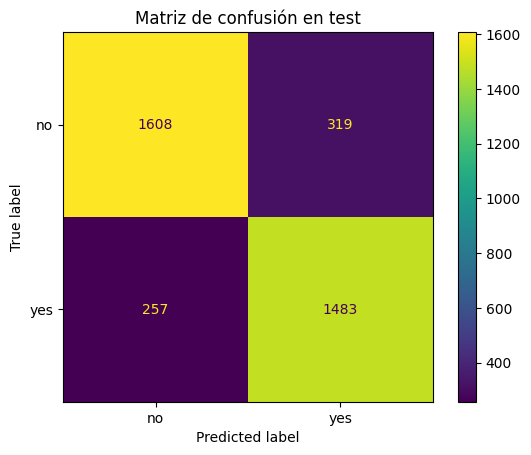

In [48]:
cm = confusion_matrix(y_test, y_pred_test, labels=["no", "yes"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no", "yes"])
disp.plot()
plt.title("Matriz de confusión en test")
plt.show()

Además de la métrica principal utilizada durante la práctica, se incluye la matriz de confusión para observar con más detalle el comportamiento del modelo sobre el conjunto de test. Esta representación permite distinguir mejor cuántos falsos positivos y falsos negativos comete la alternativa finalmente seleccionada.

## 6.4 Entrenamiento del modelo final con todos los datos disponibles

Después de estimar el rendimiento futuro sobre el conjunto de test, el modelo final se vuelve a entrenar utilizando todos los datos disponibles del dataset principal (`bank_17.pkl`), ya que ese será el modelo que se empleará para generar las predicciones del conjunto de competición.

In [49]:
X_all = df.drop("deposit", axis=1)
y_all = df["deposit"]

pipeline_modelo_final = modelos_finales[mejor_modelo_global]
pipeline_modelo_final.fit(X_all, y_all)

print("Modelo final reentrenado con todo el dataset principal.")

Modelo final reentrenado con todo el dataset principal.


## 6.5 Guardado del modelo final

In [55]:
import joblib
import pickle

# Joblib
joblib.dump(pipeline_modelo_final, "modelo_final.joblib")
print("Modelo joblib guardado como modelo_final.joblib")

# Pickle
pickle_filename = "modelo_final.pkl"

# Guardar el modelo en formato .pkl
with open(pickle_filename, 'wb') as file:
    pickle.dump(pipeline_modelo_final, file)

print(f"Modelo pickle guardado como {pickle_filename}")

Modelo joblib guardado como modelo_final.joblib
Modelo pickle guardado como modelo_final.pkl


El modelo final se guarda en un fichero para poder reutilizarlo posteriormente tanto en el notebook de competición como en la aplicación de Streamlit.